In [1]:
import pandas as pd

In [2]:
# df = pd.read_parquet("part-00000-1dc0d1bc-3cdc-4fa2-a1dc-c9597cd083eb-c000.snappy.parquet")

In [3]:
# df.head(5)

In [4]:
# df2 = pd.read_parquet("part-00000-2785690b-ff9f-408f-b1bf-8eb8d2b2b92b-c000.snappy.parquet")
# df2.head(5)

In [5]:
# df3 = pd.read_json("raw_reviews_part_1 (1).jsonl", lines=True)
# import json

# payload_df = pd.json_normalize(df3["raw_payload"])

In [6]:
# payload_df

In [7]:
# df4 = pd.read_json("raw_reviews_part_1 (2).jsonl", lines=True)

# payload_df2 = pd.json_normalize(df4["raw_payload"])

In [8]:
# payload_df2

In [9]:
data = pd.read_csv("output.csv")

In [10]:
data["label"] = data["rating"].apply(
    lambda x: 1.0 if x >= 7.0 else(0.0 if pd.notna(x) else None)
)

In [11]:
data.head(5)

,review_id,imdb_id,content,rating,source_system,label
0,000524abf6de59d91f3e4a4375ec8415cc5a9cdf1fe595...,tt27543632,"For the first hour of the movie, I honestly di...",7.0,imdb,1.0
1,000a465558f22ae39464a9830ce91dbcd7786a76ab60ab...,tt7181546,"I actual like this film a lot, this film is no...",7.0,imdb,1.0
2,002c15fdae45738c4c9a43d5db9a73b2b00c5ddd4a19fa...,tt15239678,This movie is a spell binding experience. It i...,9.0,imdb,1.0
3,00356c43c1324f1f636c22fe9926ed43b1d843360c9c40...,tt15940132,This is the second movie i've watched from Ala...,3.0,imdb,0.0
4,00448ca2411ce6bb93ec8a1cab9b0d22b559be878078d7...,tt30144839,Horrible from start to finish. Clearly made to...,2.0,imdb,0.0


In [12]:
data["label"].value_counts(normalize=True)

label
1.0    0.674941
0.0    0.325059
Name: proportion, dtype: float64

In [13]:
data.groupby("source_system")["label"].value_counts(normalize=True)

source_system  label
imdb           1.0      0.674996
               0.0      0.325004
tmdb           1.0      0.600000
               0.0      0.400000
Name: proportion, dtype: float64

In [14]:
data_clean = data.dropna(subset=["content", "label"])
X = data_clean["content"]
Y = data_clean["label"]

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [16]:
print(X_train.shape, Y_train.shape)

(54242,) (54242,)


In [17]:
print(Y_train.value_counts())

label
1.0    36610
0.0    17632
Name: count, dtype: int64


In [18]:
print(X_test.shape, Y_test.shape)

(13561,) (13561,)


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    stop_words="english",
    min_df=3        
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'solver': ["saga"]
}

grid_search = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=2000), param_grid, cv=5, scoring='f1_macro')
grid_search.fit(X_train_vec, Y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Best Parameters: {'C': 1, 'solver': 'saga'}
Best Score: 0.8560531733946366


In [21]:
best_model_lr = grid_search.best_estimator_
y_pred_final = best_model_lr.predict(X_test_vec)

In [22]:
from sklearn.metrics import classification_report, roc_auc_score
print("--- Final LR Evaluation on Test Set ---")
print(classification_report(Y_test, y_pred_final))
print("ROC-AUC Score:", roc_auc_score(Y_test, best_model_lr.predict_proba(X_test_vec)[:, 1]))

--- Final LR Evaluation on Test Set ---
              precision    recall  f1-score   support

         0.0       0.78      0.87      0.82      4408
         1.0       0.93      0.88      0.91      9153

    accuracy                           0.88     13561
   macro avg       0.85      0.87      0.86     13561
weighted avg       0.88      0.88      0.88     13561

ROC-AUC Score: 0.9420460534494953


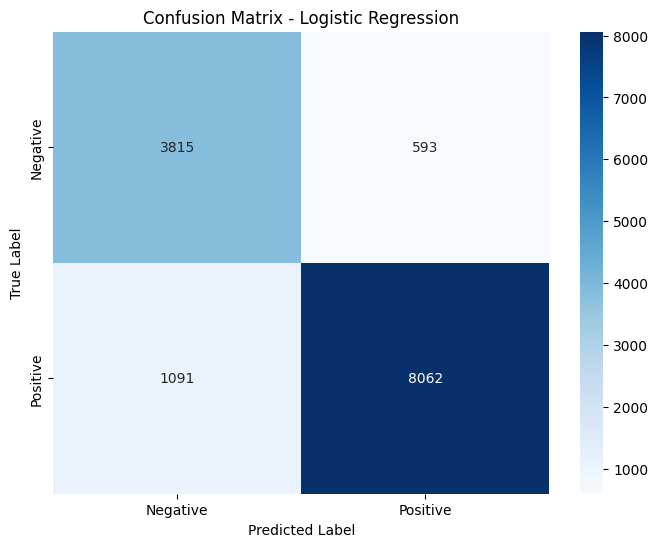

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Tính confusion matrix cho mô hình tốt nhất (ví dụ best_svc_model)
cm = confusion_matrix(Y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


In [24]:
from sklearn.svm import LinearSVC

param_grid_svm = {
    'C': [0.01, 0.1, 1, 10],            # Độ mạnh của Regularization
    'loss': ['hinge', 'squared_hinge'], # Hàm mất mát
    'max_iter': [2000]                  # Đảm bảo mô hình hội tụ
}
# 2. Khởi tạo GridSearchCV
# Sử dụng scoring='f1_macro' để cân bằng giữa cả 2 lớp (tích cực và tiêu cực)
grid_search_svc = GridSearchCV(
    LinearSVC(class_weight='balanced', random_state=42), 
    param_grid_svm, 
    cv=5, 
    scoring='f1_macro'
)

In [25]:
grid_search_svc.fit(X_train_vec, Y_train)

d:\hoc tap\ki 6\DoAnNganh\final_project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\hoc tap\ki 6\DoAnNganh\final_project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\hoc tap\ki 6\DoAnNganh\final_project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(cla...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'loss': ['hinge', 'squared_hinge'], 'max_iter': [2000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

In [ ]:
print("--- LinearSVC Tuning Results ---")
print("Best Parameters:", grid_search_svc.best_params_)
print("Best F1-Macro Score:", grid_search_svc.best_score_)

--- LinearSVC Tuning Results ---
Best Parameters: {'C': 0.1, 'loss': 'squared_hinge', 'max_iter': 2000}
Best F1-Macro Score: 0.856071641927825


In [27]:
# 5. Đánh giá trên tập Test
best_svc_model = grid_search_svc.best_estimator_
y_pred_svc_final = best_svc_model.predict(X_test_vec)

In [28]:
from sklearn.metrics import classification_report
print("\n--- Final LinearSVC Evaluation ---")
print(classification_report(Y_test, y_pred_svc_final))
y_scores_svm = best_svc_model.decision_function(X_test_vec)
print("ROC-AUC Score:", roc_auc_score(Y_test, y_scores_svm))


--- Final LinearSVC Evaluation ---
              precision    recall  f1-score   support

         0.0       0.78      0.86      0.82      4408
         1.0       0.93      0.88      0.91      9153

    accuracy                           0.88     13561
   macro avg       0.85      0.87      0.86     13561
weighted avg       0.88      0.88      0.88     13561

ROC-AUC Score: 0.9418340148311533


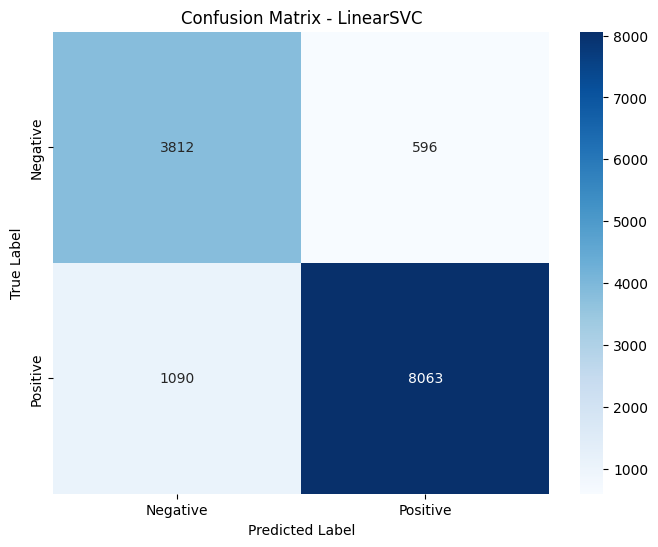

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Tính confusion matrix cho mô hình tốt nhất (ví dụ best_svc_model)
cm = confusion_matrix(Y_test, y_pred_svc_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - LinearSVC')
plt.show()


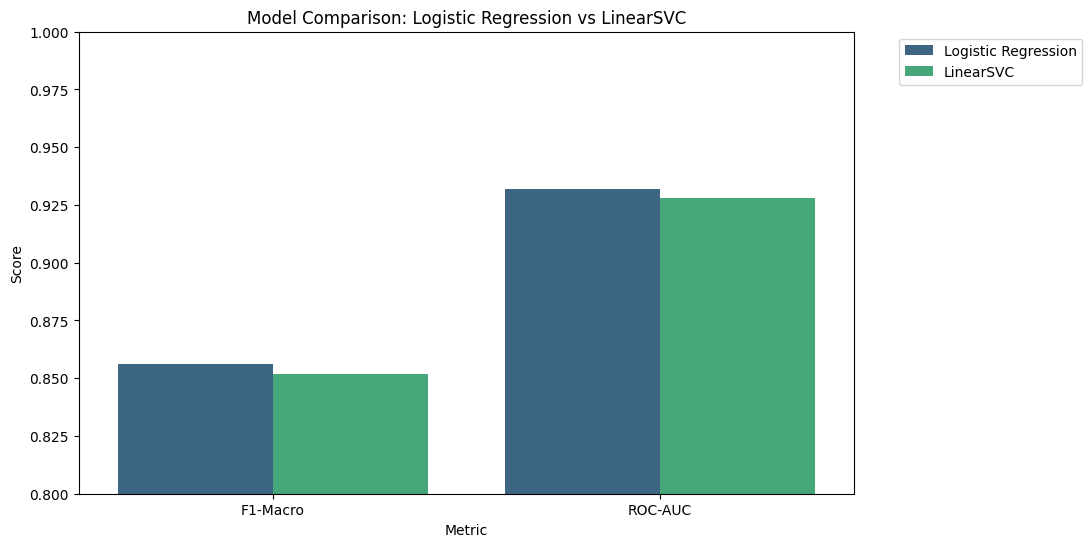

In [30]:
import pandas as pd

# Giả sử bạn đã có điểm số của 2 mô hình
data_compare = {
    'Model': ['Logistic Regression', 'LinearSVC'],
    'F1-Macro': [0.856, 0.852], # Thay bằng số thực tế của bạn
    'ROC-AUC': [0.932, 0.928]   # Thay bằng số thực tế của bạn
}

df_plot = pd.DataFrame(data_compare).melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Metric', y='Score', hue='Model', palette='viridis')
plt.ylim(0.8, 1.0) # Zoom vào phần từ 0.8 đến 1.0 để thấy sự khác biệt
plt.title('Model Comparison: Logistic Regression vs LinearSVC')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
